<a href="https://colab.research.google.com/github/MartinCarossino/scoring-riesgo-crediticio/blob/main/notebook/scoring_riesgo_crediticio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# BLOQUE 1 — CARGA DE DATOS
# ============================================
# Importamos pandas, la librería estándar para trabajar con datos tabulares en Python
import pandas as pd

# URL "raw" del CSV alojado en GitHub.
# Usamos raw.githubusercontent.com (no la URL normal de github.com) porque
# devuelve el archivo plano, sin la interfaz visual de GitHub alrededor.
URL_DATASET = "https://raw.githubusercontent.com/MartinCarossino/scoring-riesgo-crediticio/main/default_credit_card.csv"

# Leemos el CSV directo desde la URL — no hace falta descargar nada a mano
df = pd.read_csv(URL_DATASET)

# Primer vistazo: cuántas filas (clientes) y columnas (variables) tenemos
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

# Las primeras filas para ver cómo vienen los datos "crudos"
df.head()

Dimensiones del dataset: 30000 filas x 25 columnas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 1: diagnóstico)
# ============================================
# Antes de limpiar nada, miramos qué valores únicos tienen las columnas
# categóricas. Esto nos va a mostrar si hay valores "raros" que no están
# documentados en la descripción oficial del dataset.

print("Valores únicos en EDUCATION:", sorted(df['EDUCATION'].unique()))
print("Valores únicos en MARRIAGE:", sorted(df['MARRIAGE'].unique()))
print("Valores únicos en SEX:", sorted(df['SEX'].unique()))

Valores únicos en EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Valores únicos en MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Valores únicos en SEX: [np.int64(1), np.int64(2)]


In [ ]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 2: corrección de categorías)
# ============================================

# EDUCATION: los valores 0, 5 y 6 no están documentados oficialmente.
# Los agrupamos junto con el 4 ("others") en una sola categoría "otros/desconocido".
# .replace() busca esos valores puntuales y los reemplaza por 4.
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: el valor 0 no está documentado oficialmente.
# Lo agrupamos junto con el 3 ("others").
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Verificamos que ahora las categorías queden limpias
print("EDUCATION después de limpiar:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE después de limpiar:", sorted(df['MARRIAGE'].unique()))

EDUCATION después de limpiar: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE después de limpiar: [np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 3: renombrar columnas)
# ============================================

# Renombramos la columna objetivo a un nombre sin espacios, más corto y en
# minúsculas — convención estándar en Python (snake_case)
df = df.rename(columns={'default payment next month': 'default'})

# También renombramos PAY_0 a PAY_1 por consistencia: el dataset original
# tiene un typo — la secuencia salta de PAY_0 directo a PAY_2, PAY_3... PAY_6,
# sin un PAY_1. Lo corregimos para que el orden tenga sentido.
df = df.rename(columns={'PAY_0': 'PAY_1'})

# Verificamos los nombres finales de columnas
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [ ]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 4: eliminar columna ID)
# ============================================

# ID no aporta información predictiva — es solo un identificador correlativo.
# axis=1 le indica a Pandas que eliminamos una COLUMNA (axis=0 sería una fila).
df = df.drop('ID', axis=1)

# Confirmamos la forma final del dataset ya limpio
print(f"Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset limpio: 30000 filas x 24 columnas


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Conteo absoluto:
default
0    23364
1     6636
Name: count, dtype: int64

Porcentaje:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


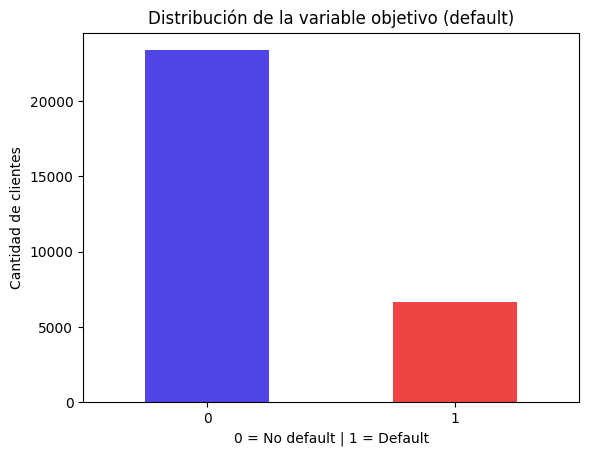

In [ ]:
# ============================================
# BLOQUE 3 — EDA (paso 1: balance de clases)
# ============================================
import matplotlib.pyplot as plt

# Contamos cuántos clientes cayeron en default (1) vs los que no (0)
conteo_default = df['default'].value_counts()
porcentaje_default = df['default'].value_counts(normalize=True) * 100

print("Conteo absoluto:")
print(conteo_default)
print("\nPorcentaje:")
print(porcentaje_default.round(2))

# Visualizamos con un gráfico de barras simple
conteo_default.plot(kind='bar', color=['#4F46E5', '#EF4444'])
plt.title('Distribución de la variable objetivo (default)')
plt.xlabel('0 = No default | 1 = Default')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# ============================================
# BLOQUE 3 — EDA (paso 2: tasa de default por grupo)
# ============================================

# groupby + mean sobre una columna binaria (0/1) te da directamente
# la PROPORCIÓN de 1s en cada grupo — es decir, la tasa de default.
# Es el mismo concepto que un AVG(default) GROUP BY columna en SQL.

print("Tasa de default por género (1=hombre, 2=mujer):")
print(df.groupby('SEX')['default'].mean().round(3))

print("\nTasa de default por nivel educativo (1=posgrado, 2=universidad, 3=secundario, 4=otros):")
print(df.groupby('EDUCATION')['default'].mean().round(3))

print("\nTasa de default por estado civil (1=casado, 2=soltero, 3=otros):")
print(df.groupby('MARRIAGE')['default'].mean().round(3))

Tasa de default por género (1=hombre, 2=mujer):
SEX
1    0.242
2    0.208
Name: default, dtype: float64

Tasa de default por nivel educativo (1=posgrado, 2=universidad, 3=secundario, 4=otros):
EDUCATION
1    0.192
2    0.237
3    0.252
4    0.071
Name: default, dtype: float64

Tasa de default por estado civil (1=casado, 2=soltero, 3=otros):
MARRIAGE
1    0.235
2    0.209
3    0.236
Name: default, dtype: float64


In [ ]:
# ============================================
# BLOQUE 3 — EDA (paso 2b: tamaño de cada grupo)
# ============================================

# Antes de confiar en una tasa, siempre hay que mirar CUÁNTOS casos
# sostienen ese número. Una tasa basada en pocos casos es poco confiable.
print("Cantidad de clientes por nivel educativo:")
print(df['EDUCATION'].value_counts().sort_index())

Cantidad de clientes por nivel educativo:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


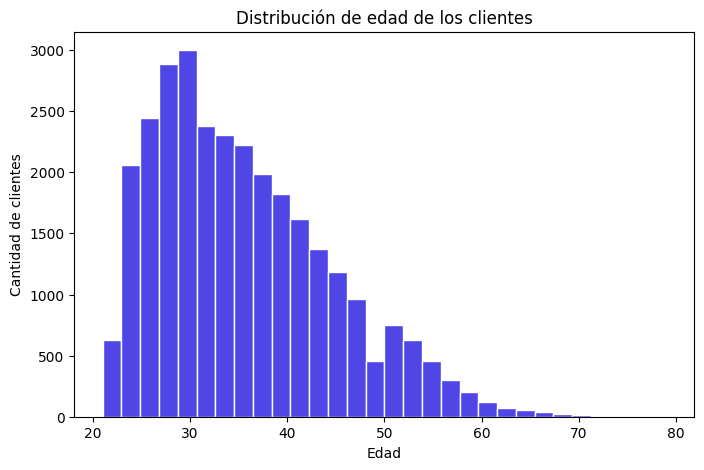

Estadísticas descriptivas de AGE:
count    30000.0
mean        35.5
std          9.2
min         21.0
25%         28.0
50%         34.0
75%         41.0
max         79.0
Name: AGE, dtype: float64


In [ ]:
# ============================================
# BLOQUE 3 — EDA (paso 3: distribución de edad)
# ============================================

# Histograma de edades — nos dice si el dataset tiene clientes de
# todas las edades por igual, o se concentra en algún rango
plt.figure(figsize=(8, 5))
plt.hist(df['AGE'], bins=30, color='#4F46E5', edgecolor='white')
plt.title('Distribución de edad de los clientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.show()

print("Estadísticas descriptivas de AGE:")
print(df['AGE'].describe().round(1))

In [ ]:
# ============================================
# BLOQUE 3 — EDA (paso 4: correlación con la variable objetivo)
# ============================================

# .corr() calcula el coeficiente de correlación de Pearson entre todas
# las variables numéricas. Nos interesa solo la columna 'default',
# ordenada de mayor a menor correlación (en valor absoluto).
correlaciones = df.corr()['default'].drop('default').sort_values(key=abs, ascending=False)

print("Correlación de cada variable con 'default' (ordenada por fuerza):")
print(correlaciones.round(3))

Correlación de cada variable con 'default' (ordenada por fuerza):
PAY_1        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
PAY_AMT5    -0.055
PAY_AMT6    -0.053
SEX         -0.040
EDUCATION    0.034
MARRIAGE    -0.028
BILL_AMT1   -0.020
BILL_AMT2   -0.014
BILL_AMT3   -0.014
AGE          0.014
BILL_AMT4   -0.010
BILL_AMT5   -0.007
BILL_AMT6   -0.005
Name: default, dtype: float64


In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 1: separar variables y train/test)
# ============================================
from sklearn.model_selection import train_test_split

# X = todas las variables predictoras (todo excepto la columna objetivo)
# y = la variable objetivo (lo que queremos predecir)
X = df.drop('default', axis=1)
y = df['default']

# Separamos 80% para entrenar y 20% para probar.
# random_state fija una "semilla" para que la división sea siempre la misma
# cada vez que corras el código — fundamental para reproducibilidad.
# stratify=y asegura que la proporción 78%/22% se mantenga igual en ambos
# conjuntos (si no, podrías terminar con un test set casualmente más
# desbalanceado que el train set).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de prueba: {X_test.shape[0]} filas")

# Verificamos que la proporción de default se mantuvo similar en ambos
print(f"\nProporción de default en train: {y_train.mean():.3f}")
print(f"Proporción de default en test: {y_test.mean():.3f}")

Tamaño de entrenamiento: 24000 filas
Tamaño de prueba: 6000 filas

Proporción de default en train: 0.221
Proporción de default en test: 0.221


In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 2: escalar variables)
# ============================================
from sklearn.preprocessing import StandardScaler

# StandardScaler transforma cada columna para que tenga media 0 y
# desvío estándar 1 — así ninguna variable domina por tener números
# más grandes en su escala original.
scaler = StandardScaler()

# IMPORTANTE: el scaler se "entrena" (fit) SOLO con los datos de train.
# Si lo entrenáramos con todo el dataset, el modelo tendría una fuga
# de información del test set (algo llamado "data leakage") — el test
# dejaría de ser una prueba honesta de generalización.
X_train_escalado = scaler.fit_transform(X_train)

# Al test set solo le aplicamos la transformación ya aprendida (transform,
# sin fit) — usando la misma media y desvío calculados en el train.
X_test_escalado = scaler.transform(X_test)

print("Escalado completo.")
print(f"Media de X_train_escalado (debería rondar 0): {X_train_escalado.mean():.4f}")
print(f"Desvío de X_train_escalado (debería rondar 1): {X_train_escalado.std():.4f}")

Escalado completo.
Media de X_train_escalado (debería rondar 0): 0.0000
Desvío de X_train_escalado (debería rondar 1): 1.0000


In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 3: entrenar regresión logística)
# ============================================
from sklearn.linear_model import LogisticRegression

# max_iter=1000 le da al algoritmo más margen para converger
# (encontrar los mejores coeficientes) — el valor por defecto (100)
# a veces no alcanza con datasets de este tamaño.
modelo = LogisticRegression(max_iter=1000, random_state=42)

# .fit() es el momento en que el modelo "aprende": ajusta los
# coeficientes para minimizar el error entre lo que predice y
# lo que realmente pasó en los datos de entrenamiento.
modelo.fit(X_train_escalado, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 4: predicciones y métricas)
# ============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# .predict() devuelve la clase predicha (0 o 1) para cada fila del test set
y_pred = modelo.predict(X_test_escalado)

# Calculamos las métricas principales
exactitud = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy (exactitud general):  {exactitud:.3f}")
print(f"Precision (de los que predijo como default, cuántos lo eran realmente): {precision:.3f}")
print(f"Recall (de los que SÍ cayeron en default, cuántos detectó):  {recall:.3f}")
print(f"F1-score (balance entre precision y recall): {f1:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte completo:")
print(classification_report(y_test, y_pred))

Accuracy (exactitud general):  0.808
Precision (de los que predijo como default, cuántos lo eran realmente): 0.690
Recall (de los que SÍ cayeron en default, cuántos detectó):  0.242
F1-score (balance entre precision y recall): 0.358

Matriz de confusión:
[[4529  144]
 [1006  321]]

Reporte completo:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 5: ajustar el umbral de decisión)
# ============================================

# En vez de .predict() (que usa el umbral fijo de 0.5), usamos
# .predict_proba() para obtener la PROBABILIDAD calculada de default
# para cada cliente del test set.
# Esto devuelve dos columnas: [probabilidad de clase 0, probabilidad de clase 1]
# Nos interesa la columna 1 (probabilidad de default).
probabilidades = modelo.predict_proba(X_test_escalado)[:, 1]

# Probamos un umbral más bajo: si la probabilidad de default supera 0.3
# (en vez de 0.5), lo clasificamos como default.
# Esto hace al modelo más "sensible" — detecta más casos de riesgo,
# aceptando que también va a marcar más falsos positivos.
umbral = 0.3
y_pred_ajustado = (probabilidades >= umbral).astype(int)

print(f"--- Resultados con umbral = {umbral} ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ajustado):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_ajustado):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_ajustado):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_ajustado):.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_ajustado))

--- Resultados con umbral = 0.3 ---
Accuracy:  0.798
Precision: 0.553
Recall:    0.460
F1-score:  0.502

Matriz de confusión:
[[4179  494]
 [ 717  610]]


In [ ]:
# ============================================
# BLOQUE 4 — MODELO (paso 6: interpretar coeficientes)
# ============================================
import numpy as np

# modelo.coef_ devuelve un coeficiente por cada variable predictora.
# Un coeficiente positivo significa que, a mayor valor de esa variable,
# MAYOR probabilidad de default. Negativo significa lo contrario.
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_[0]
})

# Ordenamos por el valor absoluto del coeficiente: nos interesa
# la FUERZA del efecto, sin importar si empuja hacia arriba o abajo
coeficientes['fuerza'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('fuerza', ascending=False)

print("Coeficientes ordenados por fuerza de impacto:")
print(coeficientes[['variable', 'coeficiente']].to_string(index=False))

Coeficientes ordenados por fuerza de impacto:
 variable  coeficiente
    PAY_1     0.660694
BILL_AMT1    -0.317783
 PAY_AMT1    -0.201346
 PAY_AMT2    -0.180058
LIMIT_BAL    -0.133697
    PAY_3     0.097000
    PAY_2     0.092795
BILL_AMT2     0.092520
EDUCATION    -0.091688
 MARRIAGE    -0.082760
      AGE     0.069492
    PAY_4     0.060546
      SEX    -0.056474
BILL_AMT3     0.047760
BILL_AMT4     0.039651
 PAY_AMT4    -0.037938
 PAY_AMT3    -0.031930
 PAY_AMT6    -0.028997
BILL_AMT5     0.025123
 PAY_AMT5    -0.022907
    PAY_6     0.018526
    PAY_5    -0.000790
BILL_AMT6     0.000114


## Conclusiones

**Sobre los datos:**
- El dataset está desbalanceado: 22.1% de los clientes cayó en default, 77.9% no.
- Se detectaron valores no documentados en EDUCATION y MARRIAGE, agrupados sin pérdida de filas.
- La edad de los clientes está sesgada hacia adultos jóvenes (concentración entre 25-40 años).

**Sobre los factores de riesgo:**
- El historial de pago reciente (PAY_1) es, por lejos, el predictor más fuerte de default —
  mucho más que cualquier variable demográfica (género, educación, estado civil).
- El límite de crédito otorgado correlaciona negativamente con el riesgo: los clientes con
  mayor límite tienden a tener menor probabilidad de default, posiblemente porque el banco
  ya los consideraba de bajo riesgo al otorgárselo.

**Sobre el modelo:**
- Con el umbral por defecto (0.5), el modelo logra 80.8% de accuracy pero solo 24.2% de
  recall — detecta menos de 1 de cada 4 clientes que efectivamente caen en default.
- Bajando el umbral a 0.3, el recall sube a 46.0% (casi el doble), a costa de bajar la
  precision de 0.69 a 0.55. Este trade-off debería decidirlo el negocio según qué error
  sea más costoso: dejar pasar un cliente riesgoso, o generar fricción con uno bueno.

**Limitaciones:**
- Los coeficientes de las variables BILL_AMT muestran signos contraintuitivos, probablemente
  por multicolinealidad entre los seis meses de facturación.
- El modelo es un punto de partida interpretable, no una solución de producción: un siguiente
  paso lógico sería probar modelos de árboles (Random Forest, XGBoost) y comparar performance.